# Car Price Prediction with Machine Learning
Regression project using the CarDekho dataset.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")


## Load Dataset

In [13]:
df = pd.read_csv("car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Dataset Information

In [14]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print("Duplicate Rows:", df.duplicated().sum())
df.describe()

(301, 9)
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64
Duplicate Rows: 2


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## Data Cleaning

In [15]:
df = df.drop_duplicates()

current_year = 2025
df["Car_Age"] = current_year - df["Year"]
df["Brand"] = df["Car_Name"].str.split().str[0]
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,11,ritz
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,12,sx4
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,8,ciaz
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,14,wagon
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,11,swift


## Exploratory Data Analysis

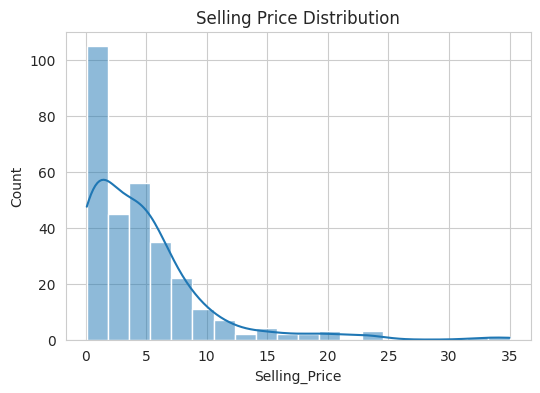

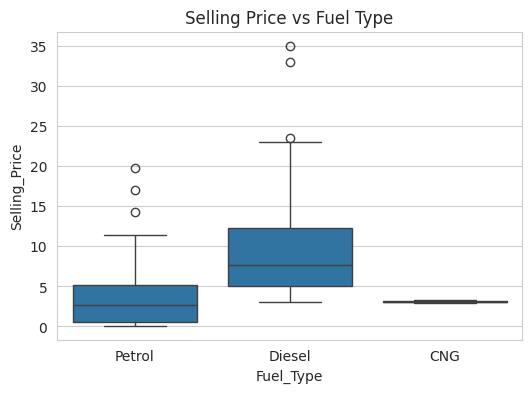

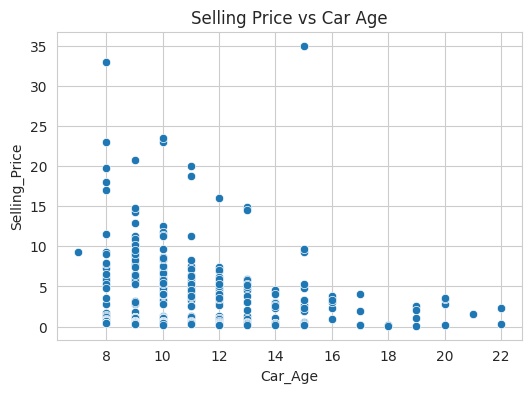

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(df["Selling_Price"], bins=20, kde=True)
plt.title("Selling Price Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x="Fuel_Type", y="Selling_Price", data=df)
plt.title("Selling Price vs Fuel Type")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x="Car_Age", y="Selling_Price", data=df)
plt.title("Selling Price vs Car Age")
plt.show()

## Correlation Heatmap

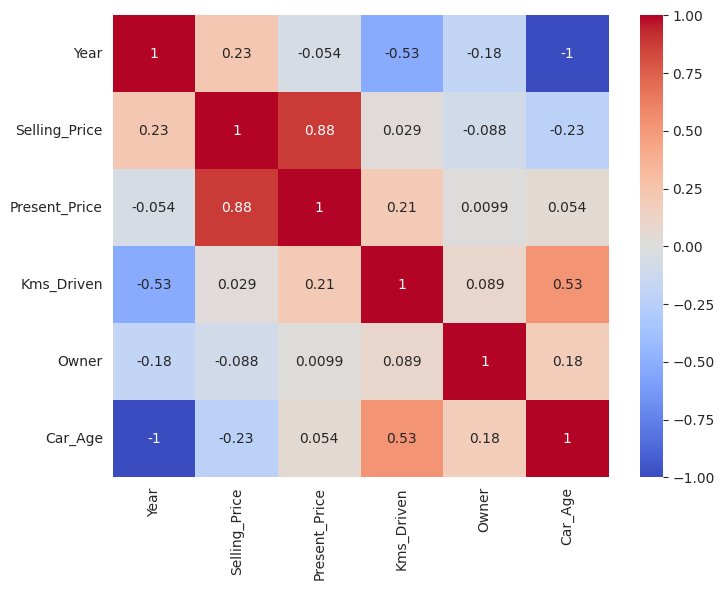

In [17]:
plt.figure(figsize=(8,6))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

## Feature Engineering & Encoding

In [18]:
X = df.drop(["Selling_Price"], axis=1)
y = df["Selling_Price"]

categorical = ["Car_Name","Fuel_Type","Seller_Type","Transmission","Brand"]
numeric = [c for c in X.columns if c not in categorical]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
    ("num","passthrough",numeric)
])

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)


## Linear Regression

In [19]:
lr = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

lr.fit(X_train,y_train)
lr_pred = lr.predict(X_test)

print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE:", mean_squared_error(y_test, lr_pred)**0.5)
print("R2  :", r2_score(y_test, lr_pred))


MAE : 1.360591892223296
RMSE: 2.5891778909371084
R2  : 0.7398915941212383


## Random Forest Regressor

In [20]:
rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestRegressor(random_state=42,n_estimators=200))
])

rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)

print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", mean_squared_error(y_test, rf_pred)**0.5)
print("R2  :", r2_score(y_test, rf_pred))


MAE : 1.4168166666666664
RMSE: 3.482481029692291
R2  : 0.5294474553667499


## Model Comparison

In [21]:
results = pd.DataFrame({
    "Model":["Linear Regression","Random Forest"],
    "MAE":[
        mean_absolute_error(y_test,lr_pred),
        mean_absolute_error(y_test,rf_pred)
    ],
    "RMSE":[
        mean_squared_error(y_test,lr_pred)**0.5,
        mean_squared_error(y_test,rf_pred)**0.5
    ],
    "R2":[
        r2_score(y_test,lr_pred),
        r2_score(y_test,rf_pred)
    ]
})

results


,Model,MAE,RMSE,R2
0,Linear Regression,1.360592,2.589178,0.739892
1,Random Forest,1.416817,3.482481,0.529447


## Feature Importance

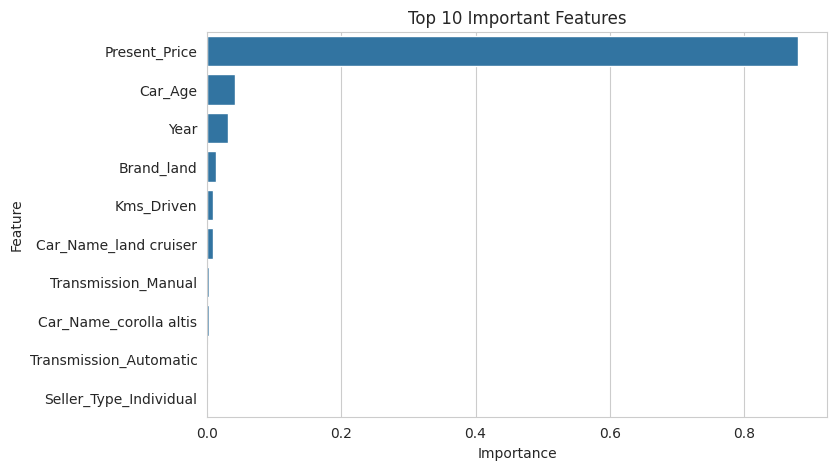

,Feature,Importance
132,Present_Price,0.879983
135,Car_Age,0.041231
131,Year,0.031255
123,Brand_land,0.012452
133,Kms_Driven,0.008623
77,Car_Name_land cruiser,0.008534
91,Transmission_Manual,0.002744
60,Car_Name_corolla altis,0.002033
90,Transmission_Automatic,0.001865
89,Seller_Type_Individual,0.001740


In [22]:
ohe = rf.named_steps["prep"].named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(categorical)
feature_names = np.concatenate([cat_names, numeric])

importances = rf.named_steps["model"].feature_importances_

fi = pd.DataFrame({
    "Feature":feature_names,
    "Importance":importances
}).sort_values("Importance",ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=fi,x="Importance",y="Feature")
plt.title("Top 10 Important Features")
plt.show()

fi


# Best Performing Model: Linear Regression
Justification:
- Linear Regression achieved the lowest Mean Absolute Error (MAE).
- It also had the lowest Root Mean Squared Error (RMSE).
- It obtained the highest R² score (0.7399), indicating it explains approximately 74% of the variance in selling prices.
- Therefore, Linear Regression is selected as the best-performing model for this dataset.